# VI + PINN training diagnostics

Plot **Stage 1 (PINN pretrain)** and **Stage 2 (VI joint train)** metrics from:

- metrics CSV files (written during training), or
- plain-text log files (`logs/log_pretrain_*`, `logs/log_train_*`)

Works locally or on the DSI cluster. Point `ARCHIVE` at your `Archive/` directory if auto-detection fails.

In [6]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display


def find_archive(explicit: Path | None = None) -> Path:
    if explicit is not None:
        explicit = Path(explicit).expanduser().resolve()
        if (explicit / "training_metrics.py").exists():
            return explicit
        raise FileNotFoundError(f"training_metrics.py not found under {explicit}")
    cwd = Path.cwd().resolve()
    if (cwd / "training_metrics.py").exists():
        return cwd
    for parent in [cwd, *cwd.parents]:
        candidate = parent / "Archive"
        if (candidate / "training_metrics.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find Archive/. Run from repo root, Archive/, or set ARCHIVE below."
    )


ARCHIVE = find_archive()  # or find_archive(Path('~/ice-dynamics/Archive'))
sys.path.insert(0, str(ARCHIVE))

from training_metrics import (
    iter_joint_figures,
    iter_pretrain_figures,
    load_joint_metrics,
    load_pretrain_metrics,
    metrics_csv_path,
    plot_joint_metrics,
    plot_pretrain_metrics,
    read_plot_paths_from_cfg,
    resolve_metrics_csv,
    resolve_plot_dir,
)

print(f"Archive: {ARCHIVE}")

Archive: /Users/anvitakallam/Ice Dynamics/Archive


## Paths

Defaults come from `run_torch.cfg` when present.

**If logs show `missing`:** they live on the cluster. From your **Mac terminal** (not in Jupyter):

```bash
mkdir -p "/Users/anvitakallam/Ice Dynamics/Archive/logs"
rsync -avz t-9akall@login.ds:~/ice-dynamics/Archive/logs/ \
           "/Users/anvitakallam/Ice Dynamics/Archive/logs/"
```

Then re-run the cells below. Override `PRETRAIN_LOG` / `JOINT_LOG` if your files are elsewhere.

In [7]:
CFG = ARCHIVE / "run_torch.cfg"
CFG_PATHS = None

if CFG.exists():
    CFG_PATHS = read_plot_paths_from_cfg(CFG)
    PRETRAIN_LOG = Path(CFG_PATHS["pretrain"].logfile)
    JOINT_LOG = Path(CFG_PATHS["joint"].logfile)
    PRETRAIN_CSV = resolve_metrics_csv(CFG_PATHS["pretrain"], CFG_PATHS["pretrain"].logfile, "pretrain")
    JOINT_CSV = resolve_metrics_csv(CFG_PATHS["joint"], CFG_PATHS["joint"].logfile, "joint")
else:
    PRETRAIN_LOG = ARCHIVE / "logs/log_pretrain_torch_more_sliding"
    JOINT_LOG = ARCHIVE / "logs/log_train_torch_more_sliding"
    PRETRAIN_CSV = metrics_csv_path(PRETRAIN_LOG, "pretrain")
    JOINT_CSV = metrics_csv_path(JOINT_LOG, "joint")

if not PRETRAIN_LOG.is_absolute():
    PRETRAIN_LOG = ARCHIVE / PRETRAIN_LOG
if not JOINT_LOG.is_absolute():
    JOINT_LOG = ARCHIVE / JOINT_LOG
if not PRETRAIN_CSV.is_absolute():
    PRETRAIN_CSV = ARCHIVE / PRETRAIN_CSV
if not JOINT_CSV.is_absolute():
    JOINT_CSV = ARCHIVE / JOINT_CSV

for label, path in [
    ("pretrain log", PRETRAIN_LOG),
    ("pretrain csv", PRETRAIN_CSV),
    ("joint log", JOINT_LOG),
    ("joint csv", JOINT_CSV),
]:
    status = "ok" if path.exists() else "missing"
    print(f"{label:12s} [{status:7s}] {path}")

missing = [p for p in (PRETRAIN_LOG, JOINT_LOG) if not p.exists()]
if missing:
    print("\nNo training logs found locally. Pull from DSI (run on your Mac):")
    print(
        '  rsync -avz t-9akall@login.ds:~/ice-dynamics/Archive/logs/ '
        f'"{ARCHIVE / "logs"}/"'
    )
    print("\nNeed at least one of pretrain log or joint log to plot.")

pretrain log [ok     ] /Users/anvitakallam/Ice Dynamics/Archive/logs/log_pretrain_torch_more_sliding
pretrain csv [missing] /Users/anvitakallam/Ice Dynamics/Archive/logs/metrics_pretrain_log_pretrain_torch_more_sliding.csv
joint log    [ok     ] /Users/anvitakallam/Ice Dynamics/Archive/logs/log_train_torch_more_sliding
joint csv    [missing] /Users/anvitakallam/Ice Dynamics/Archive/logs/metrics_joint_log_train_torch_more_sliding.csv


## Stage 1 — PINN pretrain

epochs: 1000
final train_loss=0.0908602  test_loss=0.0413935


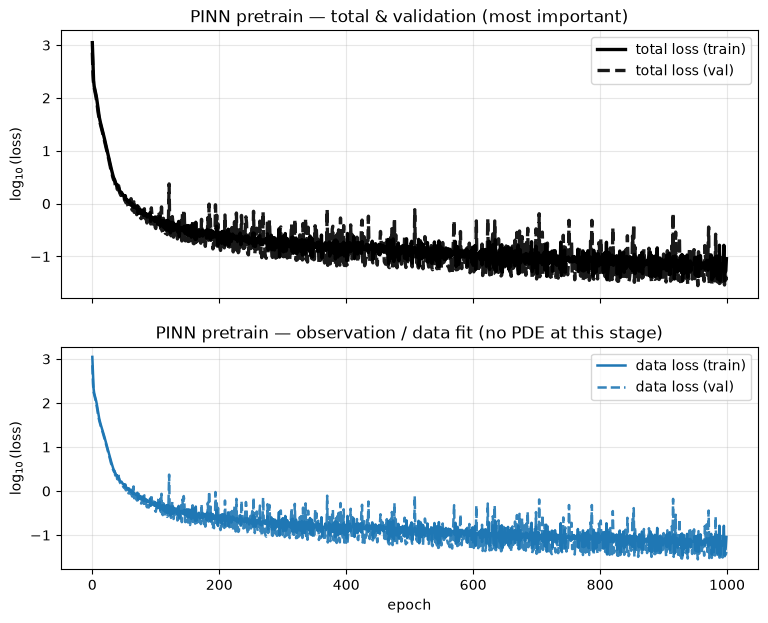

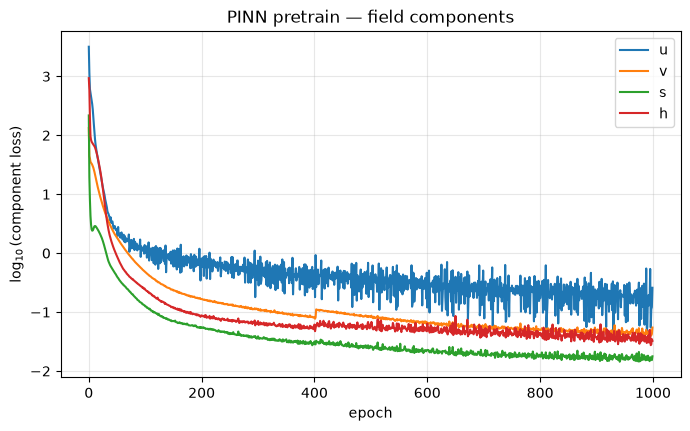

In [8]:
pretrain = load_pretrain_metrics(PRETRAIN_CSV, PRETRAIN_LOG)
print(f"epochs: {pretrain['epoch'].size}")
if pretrain['epoch'].size:
    print(
        f"final train_loss={pretrain['train_loss'][-1]:.6g}  "
        f"test_loss={pretrain['test_loss'][-1]:.6g}"
    )

for name, fig in iter_pretrain_figures(pretrain):
    display(fig)
    plt.close(fig)

## Stage 2 — VI joint train

epochs: 277
final train total=0.529525  test total=0.522228


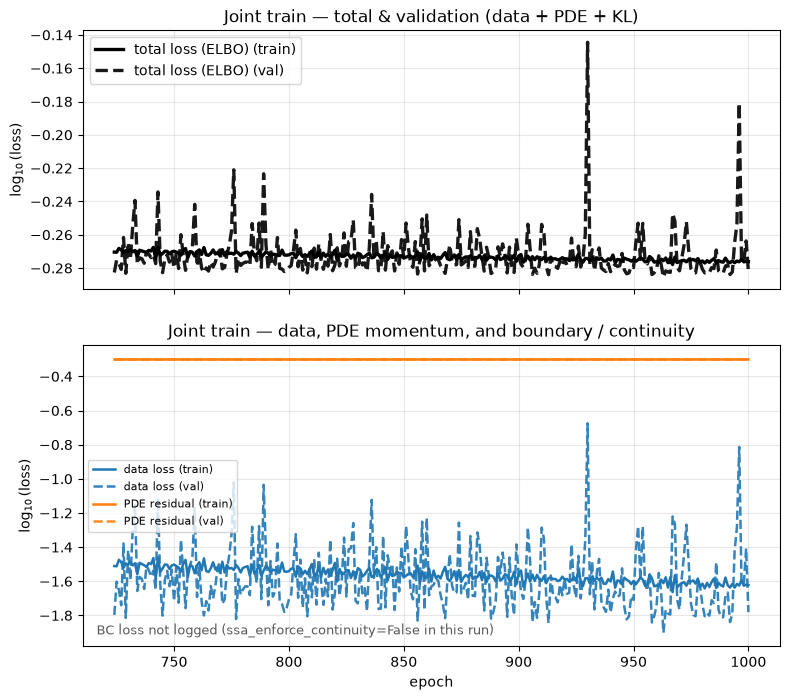

In [4]:
joint = load_joint_metrics(JOINT_CSV, JOINT_LOG)
print(f"epochs: {joint['epoch'].size}")
if joint['epoch'].size:
    print(
        f"final train total={joint['train_total'][-1]:.6g}  "
        f"test total={joint['test_total'][-1]:.6g}"
    )

for name, fig in iter_joint_figures(joint):
    display(fig)
    plt.close(fig)

## Optional — save PNGs to disk

Same figures as `python plot_training.py run_torch.cfg`.

In [5]:
SAVE_PNGS = False  # set True to write under logs/figures/

if SAVE_PNGS:
    if CFG_PATHS is not None:
        pre_dir = resolve_plot_dir(CFG_PATHS["pretrain"], CFG_PATHS["pretrain"].logfile, "pretrain")
        joint_dir = resolve_plot_dir(CFG_PATHS["joint"], CFG_PATHS["joint"].logfile, "joint")
    else:
        from training_metrics import default_plot_dir

        pre_dir = default_plot_dir(PRETRAIN_LOG, "pretrain")
        joint_dir = default_plot_dir(JOINT_LOG, "joint")

    if not Path(pre_dir).is_absolute():
        pre_dir = ARCHIVE / pre_dir
    if not Path(joint_dir).is_absolute():
        joint_dir = ARCHIVE / joint_dir

    saved_pre = plot_pretrain_metrics(pretrain, pre_dir)
    saved_joint = plot_joint_metrics(joint, joint_dir)
    print(f"saved {len(saved_pre)} pretrain + {len(saved_joint)} joint PNGs")
    for path in saved_pre + saved_joint:
        print(path)